In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


In [3]:
soup = BeautifulSoup(response.text, "html.parser")

In [4]:
books = soup.find_all("article", class_="product_pod")

len(books)

20

In [5]:
titles = []
prices = []
ratings = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p")["class"][1]

    titles.append(title)
    prices.append(price)
    ratings.append(rating)

In [6]:
books_df = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Rating": ratings
})

books_df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [17]:
books_df.dtypes

Title      object
Price     float64
Rating     object
dtype: object

In [18]:
books_df["Price"].head(10)

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
5    22.65
6    33.34
7    17.93
8    22.60
9    52.15
Name: Price, dtype: float64

In [20]:
books_df.describe()

,Price
count,20.000000
mean,38.048500
std,15.135231
min,13.990000
25%,22.637500
50%,41.380000
75%,51.865000
max,57.250000


In [21]:
books_df["Rating"].value_counts()

Rating
One      6
Four     4
Five     4
Three    3
Two      3
Name: count, dtype: int64

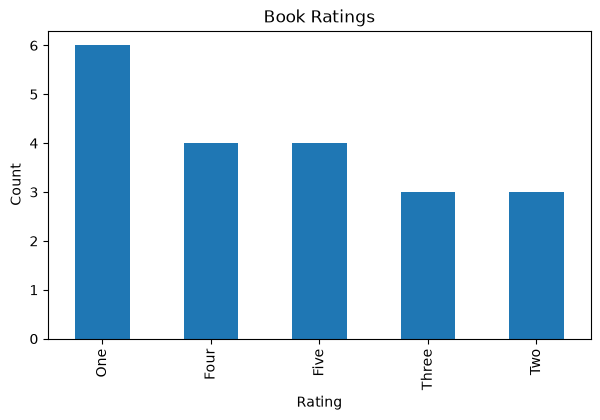

In [22]:
import matplotlib.pyplot as plt

books_df["Rating"].value_counts().plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [27]:
import os

os.makedirs("../data/scrap", exist_ok=True)

books_df.to_csv("../data/scrap/books_scraped.csv", index=False)

In [28]:
books_df.to_csv(
    "../data/scrap/books_scraped.csv",
    index=False
)